# Notebook 14 — Feature Selection Stufe 2 (Validierung)

Welche der 52 Merkmale nutzt die SVM (Stufe 2), welche fliegen raus?
Methode: **group-aware Permutation Importance** (Sessions als Gruppen) — alles mit `importance >= 0` bleibt.

In [1]:
import sys, zipfile
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GroupShuffleSplit

sys.path.insert(0, str(Path.cwd().parent / 'ml_httpstreaming'))
import classifier_app as A

# Fenster bauen (ME aus = Deploy-Default), nur die 3 Speisen
_SKIP = {'Metadata.csv', 'Annotation.csv'}
rows, lab, grp, sid = [], [], [], 0
for cls in A.CLASSES_RAW:
    for zf in sorted(A.DATA_DIR.glob(f'{cls}_*.zip')):
        with zipfile.ZipFile(zf) as z:
            n = next(x for x in z.namelist() if x.endswith('.csv') and x not in _SKIP)
            df = pd.read_csv(z.open(n))
        t = df['seconds_elapsed']
        df = df[(t >= t.iloc[0]+A.TRIM_SECS) & (t <= t.iloc[-1]-A.TRIM_SECS)].reset_index(drop=True)
        df = A._add_derived(df)
        ts = df['seconds_elapsed'].values; t0 = ts[0]
        while t0+A.MIN_WINDOW <= ts[-1]:
            w = df[(ts >= t0) & (ts < t0+A.WINDOW_SECS)].reset_index(drop=True)
            if len(w) > 1 and (w['seconds_elapsed'].iloc[-1]-w['seconds_elapsed'].iloc[0]) >= A.MIN_WINDOW and len(w) > 50:
                rows.append(A.extract_features(w)); lab.append(cls); grp.append(sid)
            t0 += A.WINDOW_SECS
        sid += 1
X = pd.DataFrame(rows); y = np.array(lab); g = np.array(grp)
spec = np.isin(y, A.FOODS)
Xe, ye, ge = X[spec].reset_index(drop=True), y[spec], g[spec]
print(f'{len(Xe)} Speise-Fenster, {len(set(ge))} Sessions, {Xe.shape[1]} Features')

711 Speise-Fenster, 67 Sessions, 52 Features


In [2]:
# group-aware Permutation Importance (identisch zur App)
def svm2():
    return Pipeline([('sc', StandardScaler()),
                     ('svm', SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42))])
imp = np.zeros(Xe.shape[1]); nd = 0
for tr, te in GroupShuffleSplit(n_splits=5, test_size=0.3, random_state=42).split(Xe.values, ye, ge):
    if len(np.unique(ye[tr])) < 2: continue
    p = svm2(); p.fit(Xe.iloc[tr], ye[tr])
    r = permutation_importance(p, Xe.iloc[te], ye[te], n_repeats=8, random_state=42, scoring='accuracy')
    imp += r.importances_mean; nd += 1
pi = pd.Series(imp/nd, index=Xe.columns).sort_values()
kept = pi[pi >= 0].index.tolist(); dropped = pi[pi < 0].index.tolist()
print(f'BEHALTEN: {len(kept)}')
print(f'ENTFERNT: {len(dropped)} -> {dropped}')

BEHALTEN: 48
ENTFERNT: 4 -> ['movement_events', 'roll_std', 'lin_x_mean', 'roll_range']


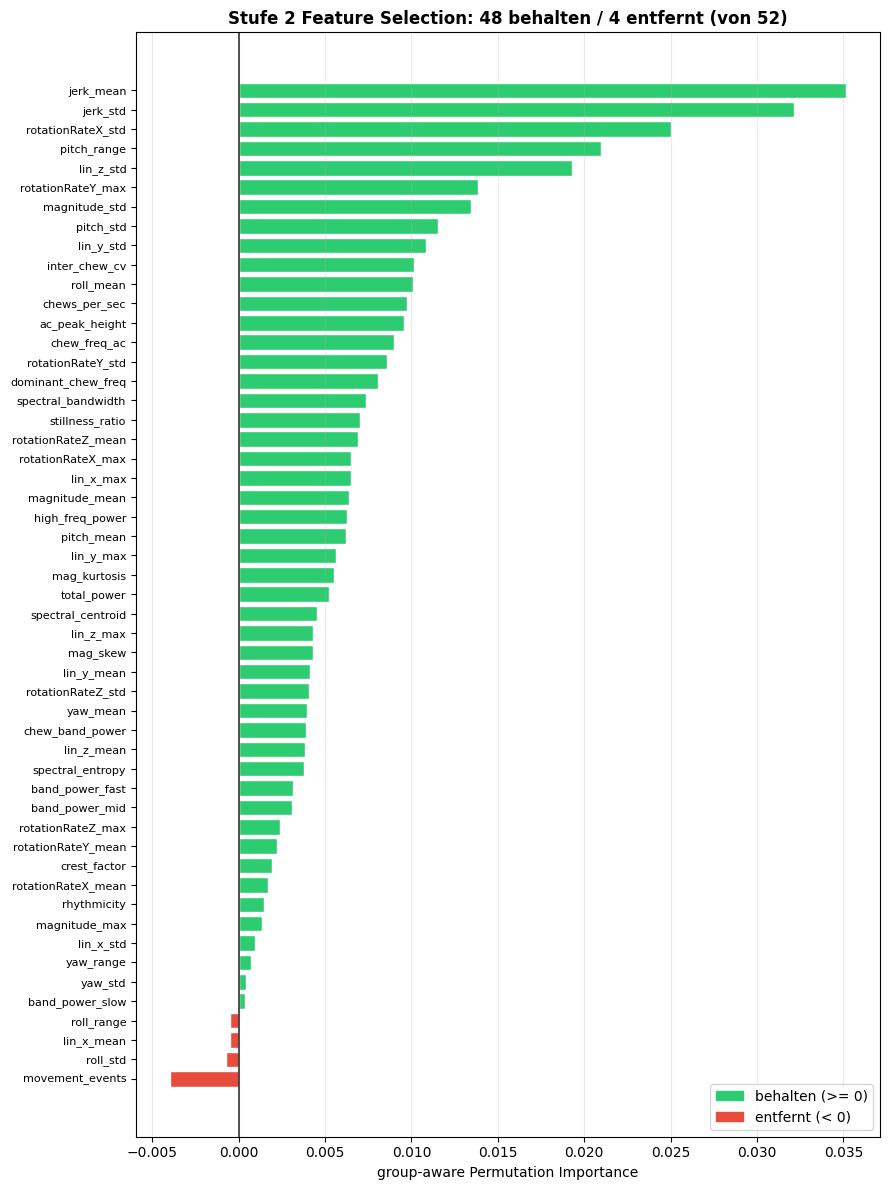

In [3]:
# Abbildung: alle 52 Merkmale nach Wichtigkeit, gruen = behalten / rot = entfernt
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in pi.values]
fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(range(len(pi)), pi.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(pi))); ax.set_yticklabels(pi.index, fontsize=8)
ax.axvline(0, color='#333', lw=1.2)
ax.set_xlabel('group-aware Permutation Importance')
ax.set_title(f'Stufe 2 Feature Selection: {len(kept)} behalten / {len(dropped)} entfernt (von {len(pi)})',
             fontweight='bold')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2ecc71', label='behalten (>= 0)'),
                   Patch(color='#e74c3c', label='entfernt (< 0)')], loc='lower right')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig('../reports/images/nb14_feature_selection_s2.png', dpi=150, bbox_inches='tight')
plt.show()